In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the JSON data from the file
with open('data.json', 'r') as file:
    data = pd.read_json(file)


In [5]:
data

,userId,name,profileUrl,totalRatings,totalReviews,avgRating,imageUrl
0,19185877,acacia,https://www.goodreads.com/user/show/19185877-a...,835.0,59.0,4.30,https://images.gr-assets.com/users/1597698907p...
1,169105231,kelli,https://www.goodreads.com/user/show/169105231-...,384.0,1.0,3.60,https://images.gr-assets.com/users/1692562817p...
2,38623456,steph,https://www.goodreads.com/user/show/38623456-s...,365.0,0.0,3.33,https://s.gr-assets.com/assets/nophoto/user/f_...
3,8829118,mindy,https://www.goodreads.com/user/show/8829118-mi...,59.0,2.0,3.69,NaN
4,179297432,kourtney,https://www.goodreads.com/user/show/179297432-...,64.0,11.0,4.28,NaN
...,...,...,...,...,...,...,...
4431,53365380,malou,https://www.goodreads.com/user/show/53365380-m...,205.0,0.0,4.12,https://s.gr-assets.com/assets/nophoto/user/u_...
4432,59821420,lisa,https://www.goodreads.com/user/show/59821420-l...,262.0,449.0,3.11,https://images.gr-assets.com/users/1734004183p...
4433,38322134,valree,https://www.goodreads.com/user/show/38322134-v...,119.0,13.0,4.27,NaN
4434,7655754,bec,https://www.goodreads.com/user/show/7655754-bec,273.0,95.0,4.14,https://images.gr-assets.com/users/1374625553p...


In [6]:
df = data.drop_duplicates()

In [7]:
df.head()

,userId,name,profileUrl,totalRatings,totalReviews,avgRating,imageUrl
0,19185877,acacia,https://www.goodreads.com/user/show/19185877-a...,835.0,59.0,4.30,https://images.gr-assets.com/users/1597698907p...
1,169105231,kelli,https://www.goodreads.com/user/show/169105231-...,384.0,1.0,3.60,https://images.gr-assets.com/users/1692562817p...
2,38623456,steph,https://www.goodreads.com/user/show/38623456-s...,365.0,0.0,3.33,https://s.gr-assets.com/assets/nophoto/user/f_...
3,8829118,mindy,https://www.goodreads.com/user/show/8829118-mi...,59.0,2.0,3.69,NaN
4,179297432,kourtney,https://www.goodreads.com/user/show/179297432-...,64.0,11.0,4.28,NaN


In [8]:
df_new = df.copy(deep=True)

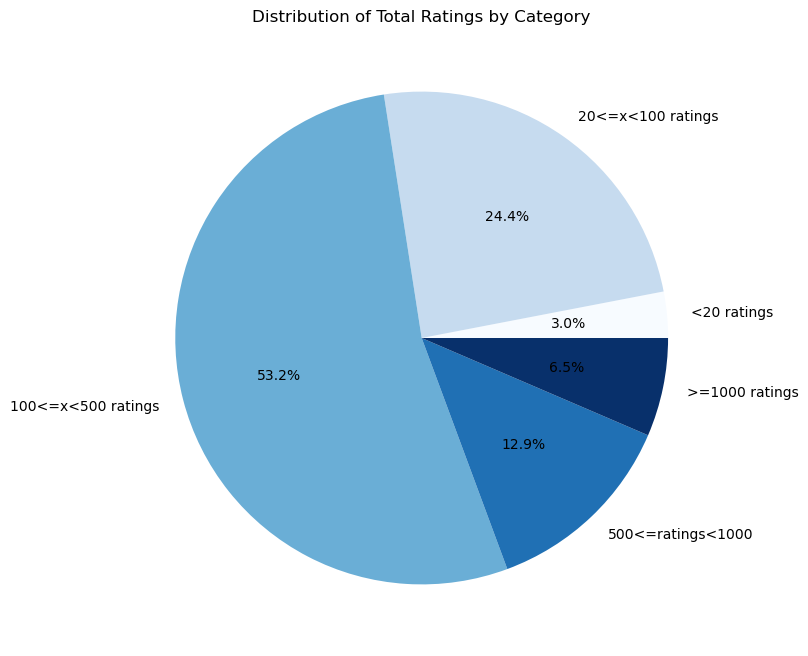

In [9]:
# Convert the 'totalRatings' column to numeric type
df_new['totalRatings'] = pd.to_numeric(df_new['totalRatings'])

# Define the rating categories
bins = [0, 20, 100, 500, 1000, float('inf')]
labels = ['<20 ratings', '20<=x<100 ratings', '100<=x<500 ratings', '500<=ratings<1000', '>=1000 ratings']

# Categorize the total ratings
df_new['rating_category'] = pd.cut(df_new['totalRatings'], bins=bins, labels=labels, right=False)

# Count the occurrences of each category
category_counts = df_new['rating_category'].value_counts().sort_index()

# Plot the pie chart
plt.figure(figsize=(8, 8))
category_counts.plot(kind='pie', autopct='%1.1f%%', startangle=360, colormap = 'Blues')
plt.title('Distribution of Total Ratings by Category')
plt.ylabel('')
plt.show()


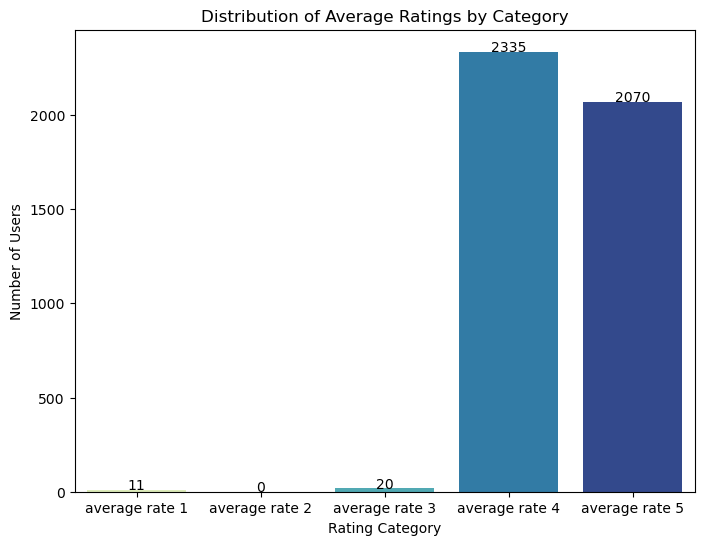

In [10]:
# Convert the 'avgRating' column to numeric type
df_new['avgRating'] = pd.to_numeric(df_new['avgRating'])

# Define the rating categories
bins = [0, 1, 2, 3, 4, float('inf')]
labels = ['average rate 1', 'average rate 2', 'average rate 3', 'average rate 4', 'average rate 5']

# Categorize the average ratings
df_new['rating_category_avg'] = pd.cut(df_new['avgRating'], bins=bins, labels=labels, right=False)

# Count the occurrences of each category
category_counts = df_new['rating_category_avg'].value_counts().sort_index()

# Plot the bar chart
plt.figure(figsize=(8, 6))
bar_plot = sns.barplot(x=category_counts.index, y=category_counts.values, palette='YlGnBu')

for index, value in enumerate(category_counts.values):
    bar_plot.text(index, value + 0.1 , str(value), color = 'black', ha = "center")
plt.title('Distribution of Average Ratings by Category')
plt.xlabel('Rating Category')
plt.ylabel('Number of Users')
plt.show()
